In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visuals
sns.set_style('whitegrid')
%matplotlib inline

In [14]:
RAW_DATA_PATH = '../data/raw/heart.csv'
PROCESSED_TRAIN_PATH = '../data/processed/train.csv'
PROCESSED_TEST_PATH = '../data/processed/test.csv'

In [15]:
try:
    df_raw = pd.read_csv(RAW_DATA_PATH)
    print("✅ Raw data loaded successfully.")
    print(f"Dataset contains {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
except FileNotFoundError:
    print(f"❌ Error: The file was not found at {RAW_DATA_PATH}")
    print("Please ensure you have downloaded the dataset and placed it in the 'data/01_raw/' directory.")

✅ Raw data loaded successfully.
Dataset contains 920 rows and 16 columns.


### Display Basic Information

In [16]:
# --- Display basic information about the dataset ---
print("First 5 rows of the raw dataset:")
display(df_raw.head())

print("\nDataset Column Types and Non-Null Counts:")
df_raw.info()

First 5 rows of the raw dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Dataset Column Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### Statistical Summary

In [17]:
# --- Get a statistical summary of the numerical features ---
print("\nStatistical summary of numerical features:")
display(df_raw.describe())


Statistical summary of numerical features:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### Check for Missing Values

In [18]:
# --- Check for missing (null) values in each column ---
print("\nChecking for missing values:")
missing_values = df_raw.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("✅ No missing values found.")


Checking for missing values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


Visualize Target Variable Distribution

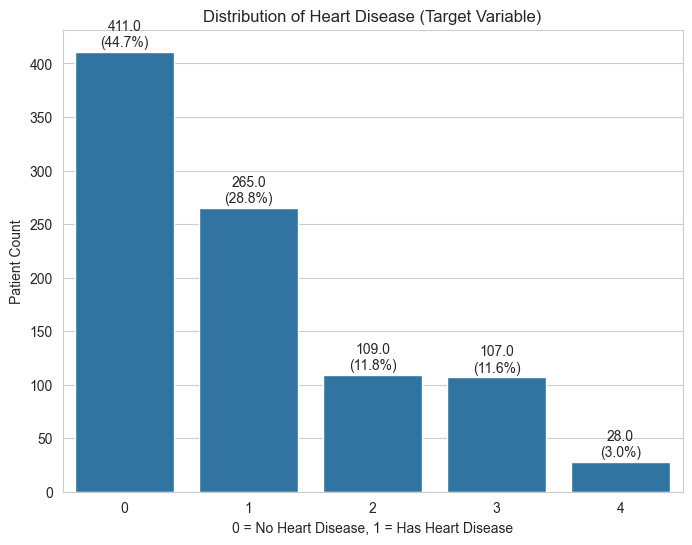

In [19]:
# --- Visualize the distribution of the target variable ---
# This helps us understand the balance of our dataset.
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df_raw)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('0 = No Heart Disease, 1 = Has Heart Disease')
plt.ylabel('Patient Count')
# Adding annotations
total = len(df_raw)
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5, f'{height}\n({height/total:.1%})', ha="center")
plt.show()

### Explore Feature Relationships

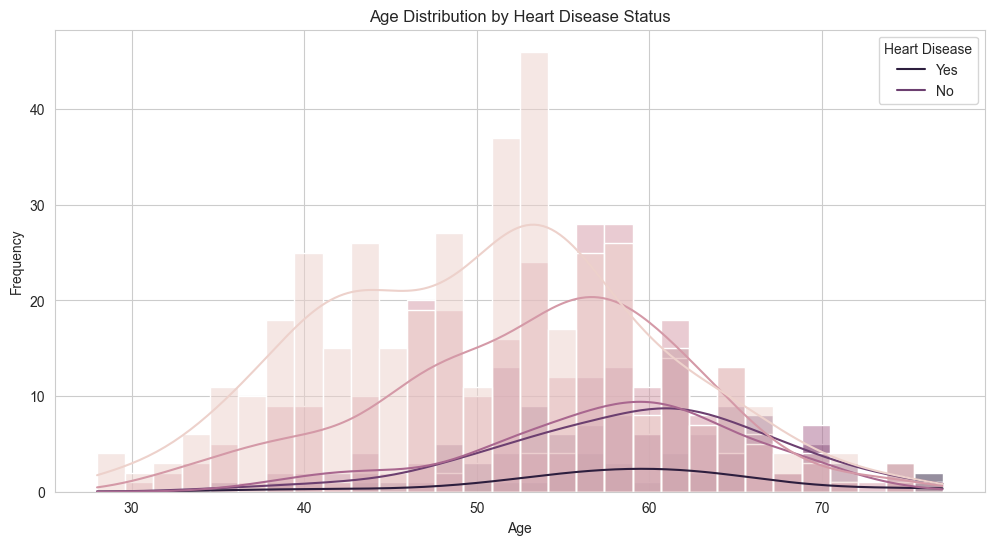

In [21]:
# --- Visualize the age distribution with respect to the target ---
plt.figure(figsize=(12, 6))
sns.histplot(data=df_raw, x='age', hue='num', kde=True, bins=30)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(title='Heart Disease', labels=['Yes', 'No'])
plt.show()